# 📊 Day 4 — Matplotlib & Exploratory Data Analysis

**What you'll learn today:**
- Draw charts using Matplotlib (Figure & Axes model)
- Draw statistical charts using Seaborn
- Systematically explore a real dataset before building any model
- Understand why correlation ≠ causation
- Detect and handle outliers

**Dataset:** *Automobile Imports 1985* — 205 real car records, 26 columns, 22 makes.  
Missing values are encoded as `?` in the raw file — you will encounter and handle them.

> 💡 **Rule of thumb:** A data scientist who skips EDA and jumps straight to a model is flying blind.  
> Numbers in a table hide shape, skew, clusters, and outliers that a chart reveals in seconds.

## 🔧 Setup — Import Libraries & Load Data

In [4]:
%pip install seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from scipy import stats

plt.style.use('seaborn-v0_8')
print('Libraries loaded ✅')

Libraries loaded ✅


In [6]:
columns = [
    'symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration',
    'num_of_doors', 'body_style', 'drive_wheels', 'engine_location',
    'wheel_base', 'length', 'width', 'height', 'curb_weight',
    'engine_type', 'num_of_cylinders', 'engine_size', 'fuel_system',
    'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm',
    'city_mpg', 'highway_mpg', 'price'
]


url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'
# path = r"/Users/raj/Desktop/ML_learning/imports-85.data"
df_raw = pd.read_csv(url, names=columns, na_values='?')

print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (205, 26)


,symboling,normalized_losses,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0


In [7]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-null    str    
 3   fuel_type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num_of_doors       203 non-null    str    
 6   body_style         205 non-null    str    
 7   drive_wheels       205 non-null    str    
 8   engine_location    205 non-null    str    
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    str    
 15  num_of_cylinders   205 non-null    str    
 16  engine_size        205 non-null    in

---
# Part 1 — Matplotlib Foundations

## The Object Model

Every Matplotlib chart has two objects:

```
Figure  ← the blank canvas (the whole window)
  └── Axes  ← the actual plot area (x-axis, y-axis, title, data)
```

You get both with:
```python
fig, ax = plt.subplots()
```
All real work happens on the **Axes** — `ax.scatter()`, `ax.set_title()`, `ax.set_xlabel()`, etc.

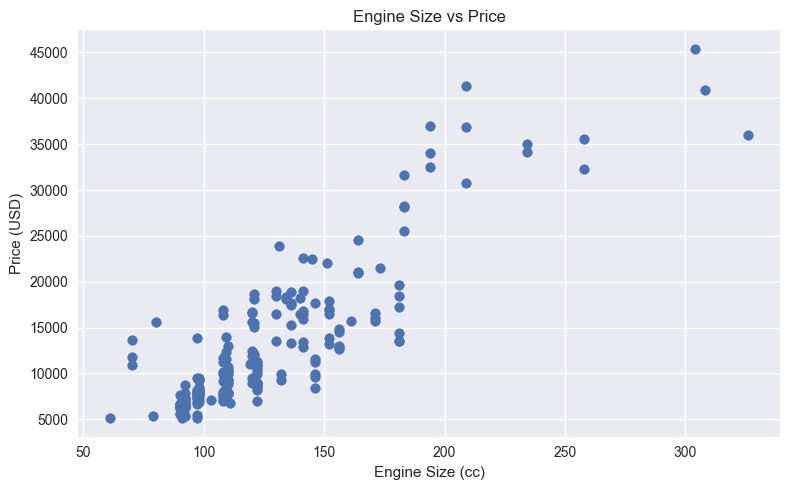

In [8]:
# Quick numeric conversion for plotting
df_plot = df_raw.copy()
for col in ['engine_size', 'price', 'horsepower', 'curb_weight']:
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# ── TASK 1 ──────────────────────────────────────────────────────────────────
# Create a scatter plot of engine_size (x) vs price (y)
# Use: fig, ax = plt.subplots(figsize=(8, 5))
# Add title, x-label, y-label, and a grid (alpha=0.3)
# Set marker colour to '#2196F3', alpha=0.6
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

# YOUR CODE HERE
ax.scatter(
    df_plot['engine_size'],
    df_plot["price"],
    
)

ax.set_title("Engine Size vs Price")
ax.set_xlabel("Engine Size (cc)")
ax.set_ylabel("Price (USD)")


plt.tight_layout()
plt.show()


# 📝 What pattern do you notice between engine size and price?
# ...

## Multi-Panel Layouts

`plt.subplots(rows, cols)` creates a grid of Axes objects.  
With a 2×2 grid, `axes` becomes a 2D array: `axes[0][0]`, `axes[0][1]`, `axes[1][0]`, `axes[1][1]`.

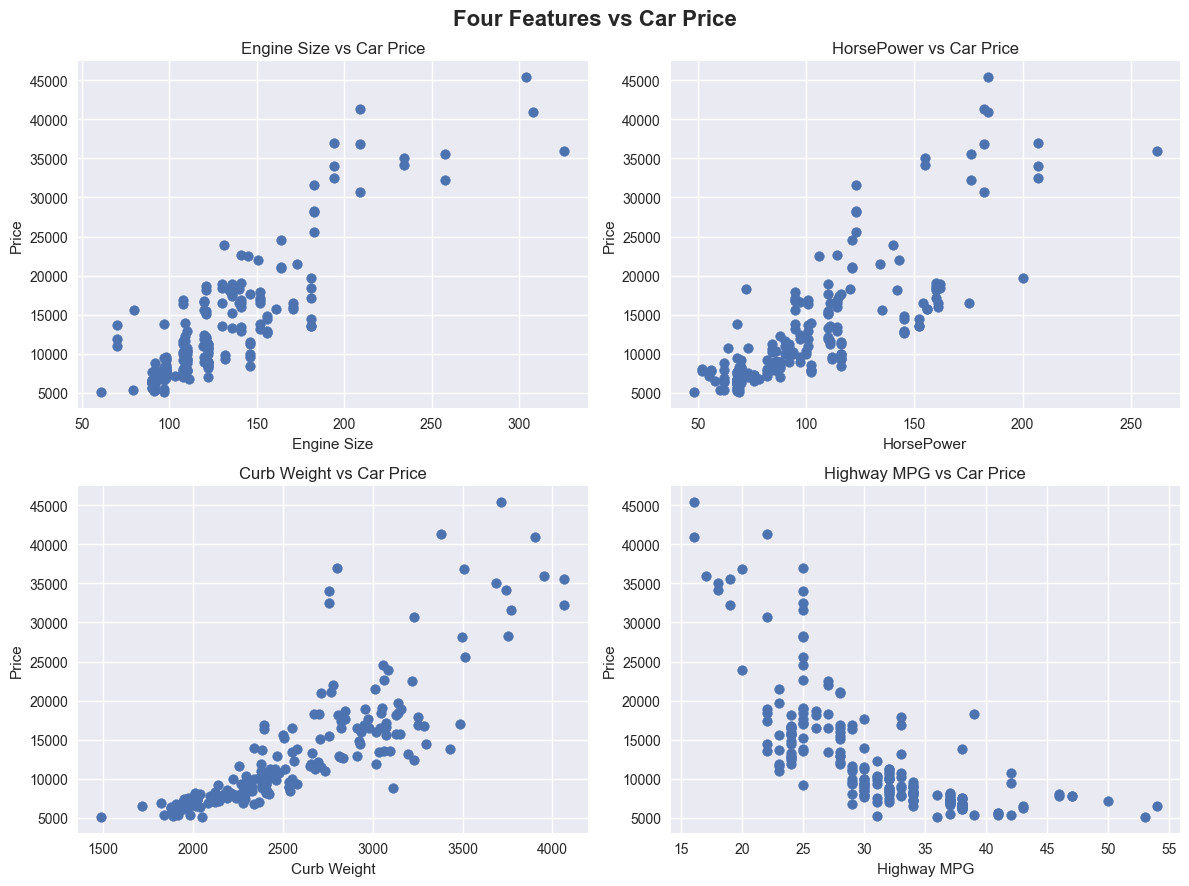

In [9]:
# ── TASK 2 ──────────────────────────────────────────────────────────────────
# Create a 2×2 subplot grid (figsize=(12, 9)) showing:
#   [0][0]  engine_size vs price      colour '#2196F3'
#   [0][1]  horsepower  vs price      colour '#E91E63'
#   [1][0]  curb_weight vs price      colour '#4CAF50'
#   [1][1]  highway_mpg vs price      colour '#FF9800'
# Each subplot needs a title, x-label, y-label, and grid(alpha=0.3)
# After plotting, save the figure as 'four_features_vs_price.png'
#   Use dpi=300 and bbox_inches='tight'
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
# print(axes)
# print(axes.flatten())
# YOUR CODE HERE
scatter_config = [
    ('engine_size', 'price', 'Engine Size'),
    ('horsepower', 'price', 'HorsePower'),
    ('curb_weight', 'price', 'Curb Weight'),
    ('highway_mpg', 'price', 'Highway MPG'),
    
]
for ax, (x_col,y_col, label) in zip(axes.flatten(), scatter_config):
    ax.scatter(df_plot[x_col],df_plot[y_col])
    ax.set_title(f"{label} vs Car Price")
    ax.set_xlabel(label)
    ax.set_ylabel("Price")

plt.suptitle('Four Features vs Car Price', fontsize=16, fontweight='bold')
plt.tight_layout()

# Save — dpi=300 is print quality; bbox_inches='tight' removes whitespace padding
# YOUR CODE HERE (plt.savefig ...)

plt.show()

# 📝 Which feature shows the strongest relationship with price? Which the weakest?
# ...

---
# Part 2 — Seaborn for Statistical Visualisation

**Seaborn is built on top of Matplotlib** — every Seaborn chart is a Matplotlib figure underneath.  
This means all your `ax.set_title()`, `ax.grid()` etc. still work on Seaborn charts.

Seaborn adds: automatic confidence intervals, grouping by category, built-in colour palettes, and distribution overlays.

---
## 2A — Categorical Charts

In [10]:
# Clean dataset for seaborn charts
df_clean = df_raw.copy()
for col in ['price', 'horsepower', 'engine_size', 'curb_weight',
            'highway_mpg', 'city_mpg', 'wheel_base', 'length',
            'width', 'normalized_losses', 'bore', 'stroke', 'peak_rpm']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
df_clean = df_clean.dropna(subset=['price'])
print(f'Clean dataset: {df_clean.shape}')

Clean dataset: (201, 26)


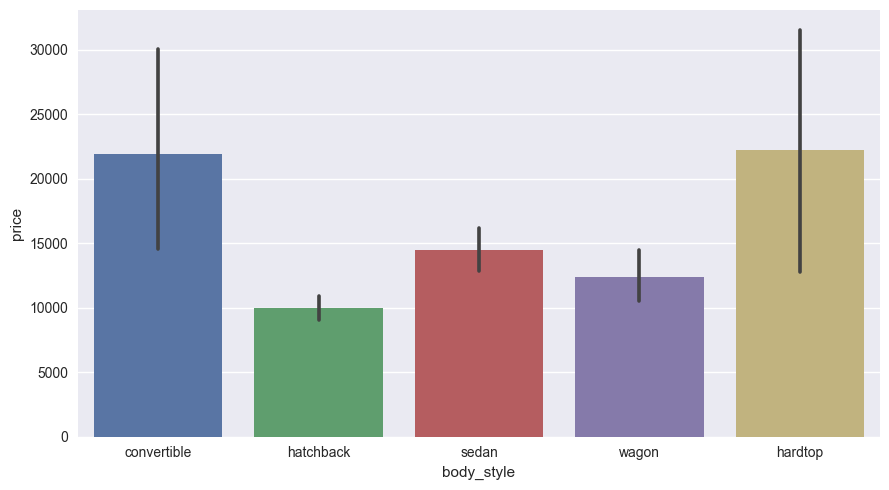

In [11]:
# ── TASK 3 — Bar Plot ────────────────────────────────────────────────────────
# Plot average price by body_style using sns.barplot
# Parameters to use: data, x, y, estimator='mean', palette='Blues_d'
# Add title: 'Average Car Price by Body Style'
# The thin error bars Seaborn draws automatically are 95% confidence intervals
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

# YOUR CODE HERE
sns.barplot(
    data = df_clean,
    x = 'body_style',
    y ='price',
    ax = ax,
    estimator = 'mean',
    hue = 'body_style'
)

plt.tight_layout()
plt.show()

# 📝 Which body style is most expensive on average? Which is cheapest?
# ...

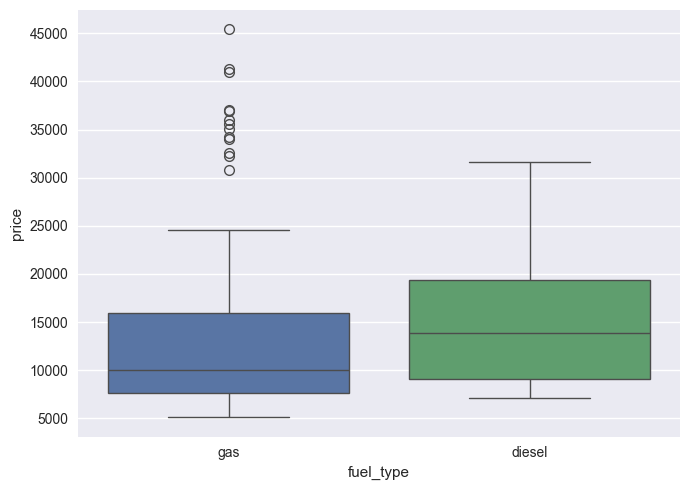

In [12]:
# Reading a box plot:
#
#   Whisker top  = Q3 + 1.5 × IQR
#   Box top      = Q3  (75th percentile)
#   Line inside  = Median (50th percentile)
#   Box bottom   = Q1  (25th percentile)
#   Whisker base = Q1 - 1.5 × IQR
#   Individual dots beyond whiskers = Outliers

# ── TASK 4 — Box Plot ────────────────────────────────────────────────────────
# Plot price distribution by fuel_type using sns.boxplot
# palette='Set2'
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5))

# YOUR CODE HERE
sns.boxplot(
    data = df_clean,
    x = 'fuel_type',
    y = 'price',
    hue = 'fuel_type',
    ax = ax
)

plt.tight_layout()
plt.show()

# 📝 Which fuel type has a higher median price? Which has more outliers?
# ...

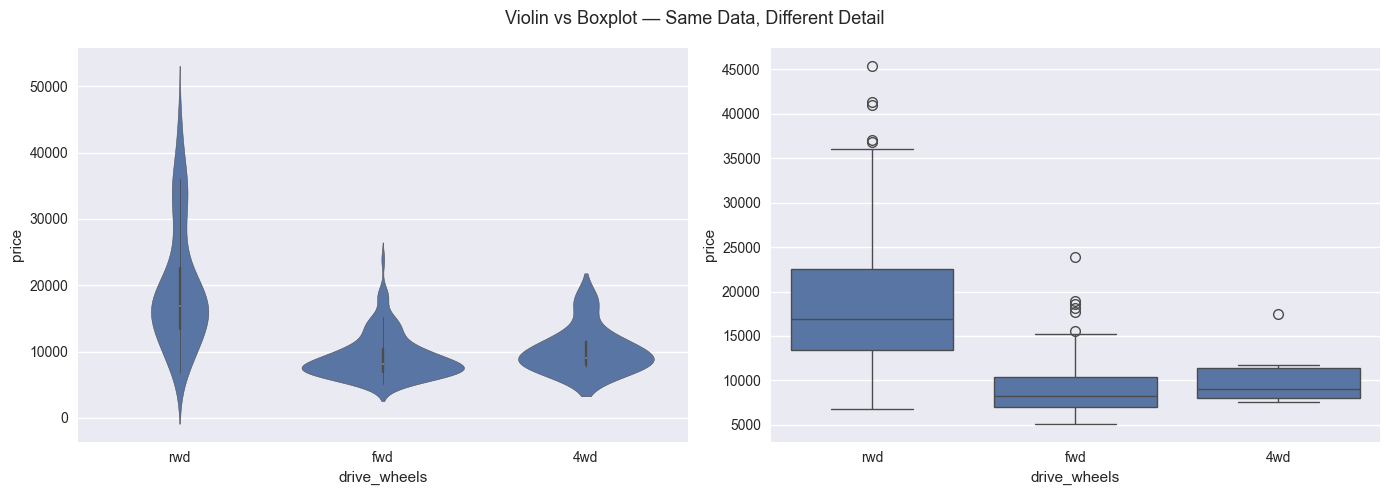

In [13]:
# ── TASK 5 — Violin vs Box ───────────────────────────────────────────────────
# Create a side-by-side comparison (1×2 subplots, figsize=(14,5))
# Left:  sns.violinplot  — drive_wheels vs price
# Right: sns.boxplot     — drive_wheels vs price  (same data)
# palette='muted' for both
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# YOUR CODE HERE
sns.violinplot(
    data = df_clean,
    x= 'drive_wheels',
    y = 'price',
    ax = axes[0]
)

sns.boxplot(
    data = df_clean,
    x= 'drive_wheels',
    y = 'price',
    ax = axes[1]
)

plt.suptitle('Violin vs Boxplot — Same Data, Different Detail', fontsize=13)
plt.tight_layout()
plt.show()

# 📝 What information is visible in the violin but hidden in the box?
# When would you choose each?
# ...

## 2B — Distribution Charts

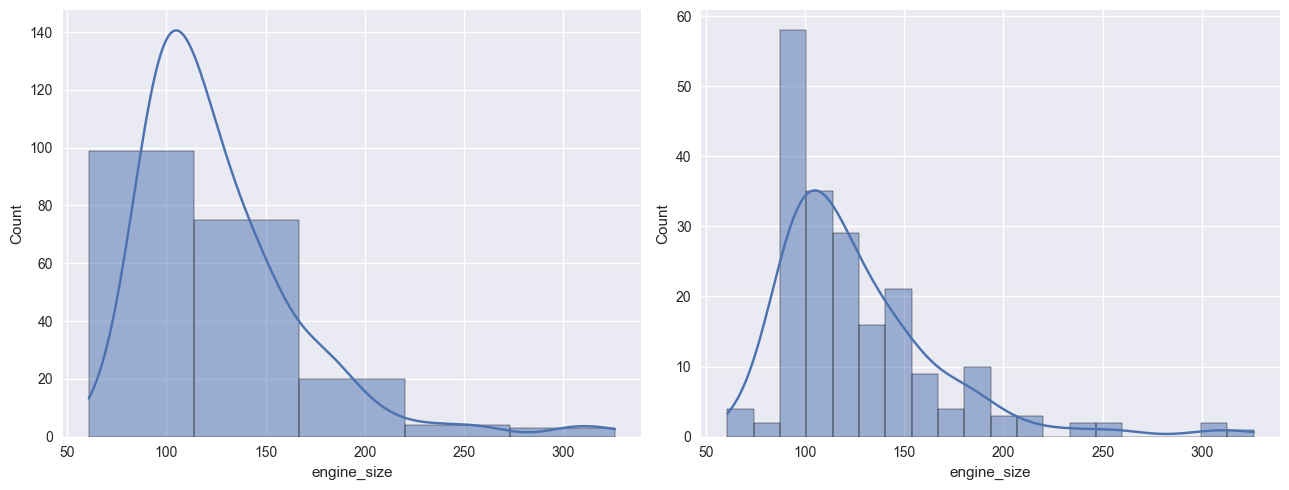

In [14]:
# ── TASK 6 — Histogram bin comparison ───────────────────────────────────────
# Create 1×2 subplots (figsize=(13,5))
# Left:  sns.histplot of engine_size, bins=5,  kde=True, colour '#2196F3'
# Right: sns.histplot of engine_size, bins=20, kde=True, colour '#2196F3'
# Title each: 'Engine Size (bins=5 — too coarse)' and 'Engine Size (bins=20 — better)'
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# YOUR CODE HERE
sns.histplot(
    df_clean['engine_size'].dropna(), 
    bins = 5,
    kde = True,
    ax = axes[0]
)
sns.histplot(
    df_clean['engine_size'].dropna(), 
    bins = 20,
    kde = True,
    ax = axes[1]
)


plt.tight_layout()
plt.show()

# 📝 Is engine_size left-skewed, right-skewed, or roughly symmetric?
# ...

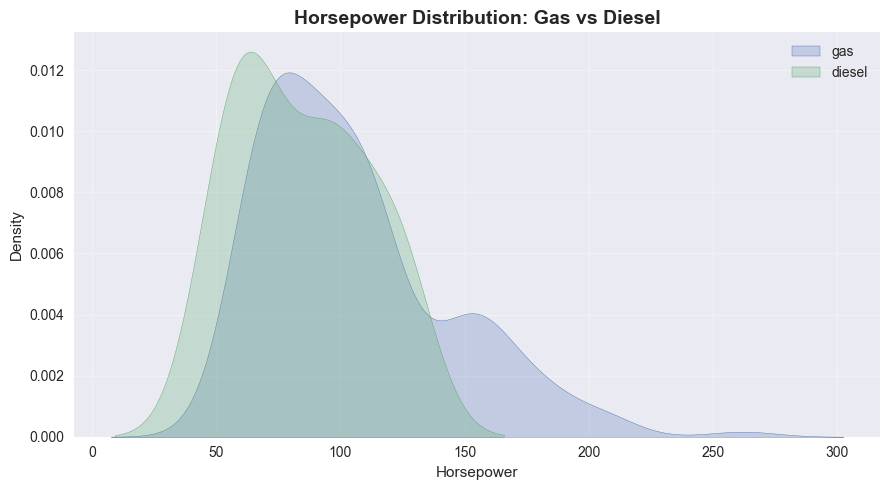

In [15]:
# ── TASK 7 — Overlapping KDE ─────────────────────────────────────────────────
# Plot horsepower KDE for gas cars AND diesel cars on the same axes
# Loop over fuel types: gas='#2196F3', diesel='#FF5722'
# Use fill=True, alpha=0.3 on each kdeplot
# Include a legend showing fuel type and sample size: e.g. 'Gas (n=184)'
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

# YOUR CODE HERE

for fuel in ['gas', 'diesel']:
    subset = df_clean[df_clean['fuel_type'] == fuel]['horsepower'].dropna()
    sns.kdeplot(subset, label= f"{fuel}",fill = True)
    
    
    
    
ax.set_title('Horsepower Distribution: Gas vs Diesel', fontsize=14, fontweight='bold')
ax.set_xlabel('Horsepower')
ax.set_ylabel('Density')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# 📝 Which fuel type has a wider horsepower range?
# ...

## 2C — Correlation Heatmap

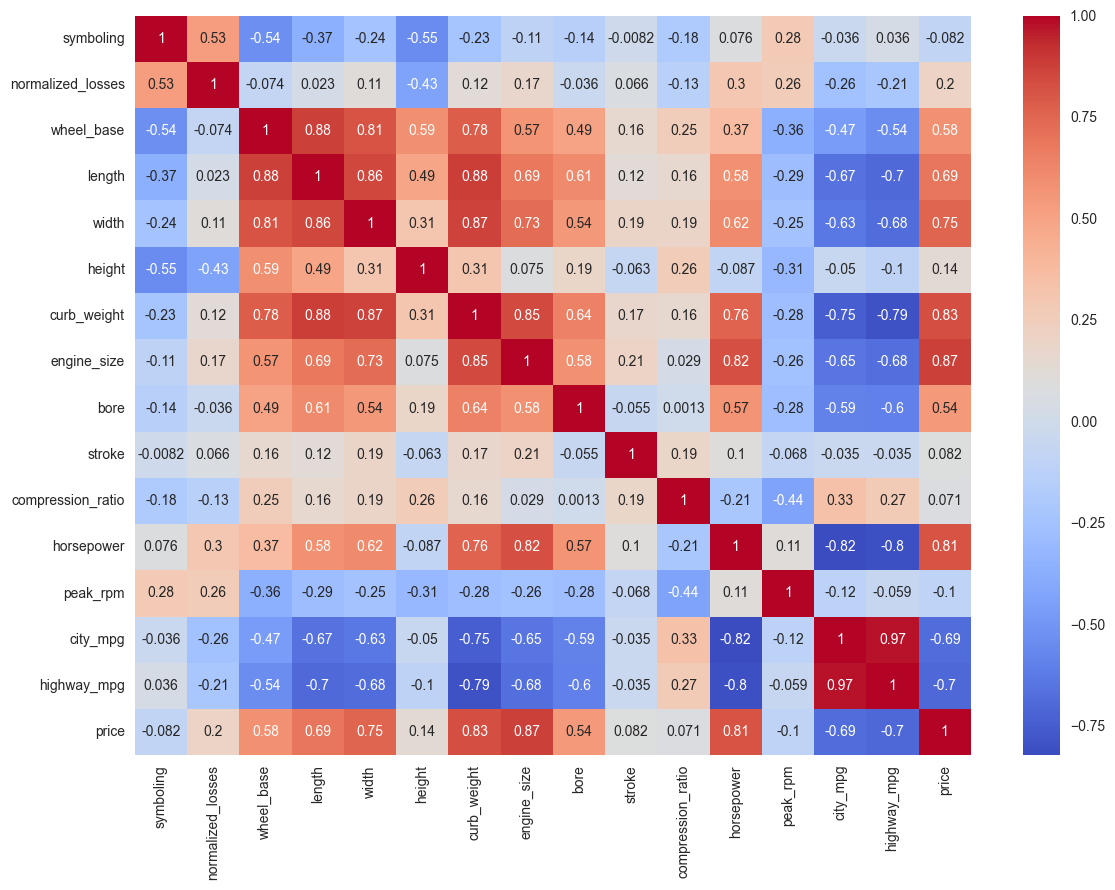

In [16]:
# ── TASK 8 — Correlation Heatmap ────────────────────────────────────────────
# 1. Compute the correlation matrix for all numeric columns in df_clean
#    Use: df_clean.select_dtypes(include='number').corr()
# 2. Plot it with sns.heatmap:
#    annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5
# 3. Use figsize=(12, 9)
# ─────────────────────────────────────────────────────────────────────────────

# YOUR CODE HERE
numeric_cols = df_clean.select_dtypes(include= 'number')
corr_matrix = numeric_cols.corr()


fig, ax = plt.subplots(figsize=(12,9))
sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = 'coolwarm'
)
               
plt.tight_layout()
plt.show()        


# 📝 Find the top 3 features most correlated with 'price':
# 1. ...
# 2. ...
# 3. ...

In [17]:
# ── TASK 9 — Print top correlations with price ───────────────────────────────
# From the correlation matrix, sort features by |correlation| with 'price'
# Print the top 5 with direction (positive / negative)
# ─────────────────────────────────────────────────────────────────────────────

# YOUR CODE HERE
price_corr = corr_matrix['price'].drop('price').sort_values(key = abs, ascending = False)
price_corr


engine_size          0.872335
curb_weight          0.834415
horsepower           0.810533
width                0.751265
highway_mpg         -0.704692
length               0.690628
city_mpg            -0.686571
wheel_base           0.584642
bore                 0.543436
normalized_losses    0.203254
height               0.135486
peak_rpm            -0.101649
symboling           -0.082391
stroke               0.082310
compression_ratio    0.071107
Name: price, dtype: float64

---
# Part 3 — Feature Types & the EDA Workflow

| Type | Description | Automobile Examples |
|------|-------------|---------------------|
| **Numerical continuous** | Any value in a range | price, engine_size, horsepower |
| **Numerical discrete** | Whole numbers | symboling, city_mpg, highway_mpg |
| **Categorical nominal** | No natural order | make, fuel_type, body_style |
| **Categorical ordinal** | Has a natural order | num_of_cylinders ← stored as words! |
| **Boolean** | Two states | aspiration (std/turbo), engine_location |

> ⚠️ `num_of_cylinders` looks like a number but is stored as words (`'four'`, `'six'` ...).  
> `df.dtypes` will show it as `object`. Sorting will be **alphabetical**, not numerical.

## The 6-Step EDA Workflow

Run every step. After each output, write a one-line interpretation as a comment.

In [36]:
# ── STEP 1 — Shape ──────────────────────────────────────────────────────────
# Print number of rows and columns
# Also calculate: if 4 values are missing, what % of the dataset is that?

# YOUR CODE HERE
df_raw.shape


# df_raw.isnull().sum().count()
# 📝 Why does dataset size matter for missing values?
# ...

(205, 26)

In [19]:
# ── STEP 2 — Data Types ─────────────────────────────────────────────────────
# Print dtypes of all columns

# YOUR CODE HERE
df_raw.dtypes

# 📝 Which columns SHOULD be numeric but show as 'object'? Why?
# ...

symboling              int64
normalized_losses    float64
make                     str
fuel_type                str
aspiration               str
num_of_doors             str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_of_cylinders         str
engine_size            int64
fuel_system              str
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: object

In [35]:
# ── STEP 3 — Missing Values ─────────────────────────────────────────────────
# Create a DataFrame showing: Count of NaN and % of NaN per column
# Show only columns that have at least 1 missing value, sorted descending

# YOUR CODE HERE
nan_values_count = df_raw.isnull().sum()
nan_pct = (nan_values_count / len(df_raw) * 100).round(2)

missing_sumary = pd.DataFrame({'Count':nan_values_count, "percent":nan_pct})
missing_sumary = missing_sumary[missing_sumary['Count'] > 0]
missing_sumary


# 📝 Which column has the most missing values? What % is that?
# ...

,Count,percent
normalized_losses,41,20.00
num_of_doors,2,0.98
bore,4,1.95
stroke,4,1.95
horsepower,2,0.98
peak_rpm,2,0.98
price,4,1.95


In [ ]:
# ── STEP 3b — Apply Cleaning Strategy ───────────────────────────────────────
# Rules:
#   price            → DROP rows (can't model without the target)
#   normalized_losses→ fill with MEDIAN  (41 missing — too many to drop)
#   bore, stroke, horsepower, peak_rpm → fill with column MEDIAN
#   num_of_doors     → fill with MODE

df = df_raw.copy()

# Convert to numeric first
for col in ['normalized_losses', 'bore', 'stroke', 'horsepower', 'peak_rpm', 'price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# YOUR CODE HERE — apply the cleaning rules above
df = df.dropna(subset=['price'])

for col in ['normalized_losses', 'bore', 'stroke', 'horsepower', 'peak_rpm']:
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f'Filled {col} with Median = {med}')
    
    
df['num_of_doors'] = df['num_of_doors'].fillna(df['num_of_doors'].mode()[0])


print(f'Final shape: {df.shape}')
print(f'Remaining NaNs: {df.isnull().sum().sum()}')

Filled normalized_losses with Median = 115.0
Filled bore with Median = 3.31
Filled stroke with Median = 3.29
Filled horsepower with Median = 95.0
Filled peak_rpm with Median = 5200.0
Final shape: (201, 26)
Remaining NaNs: 0


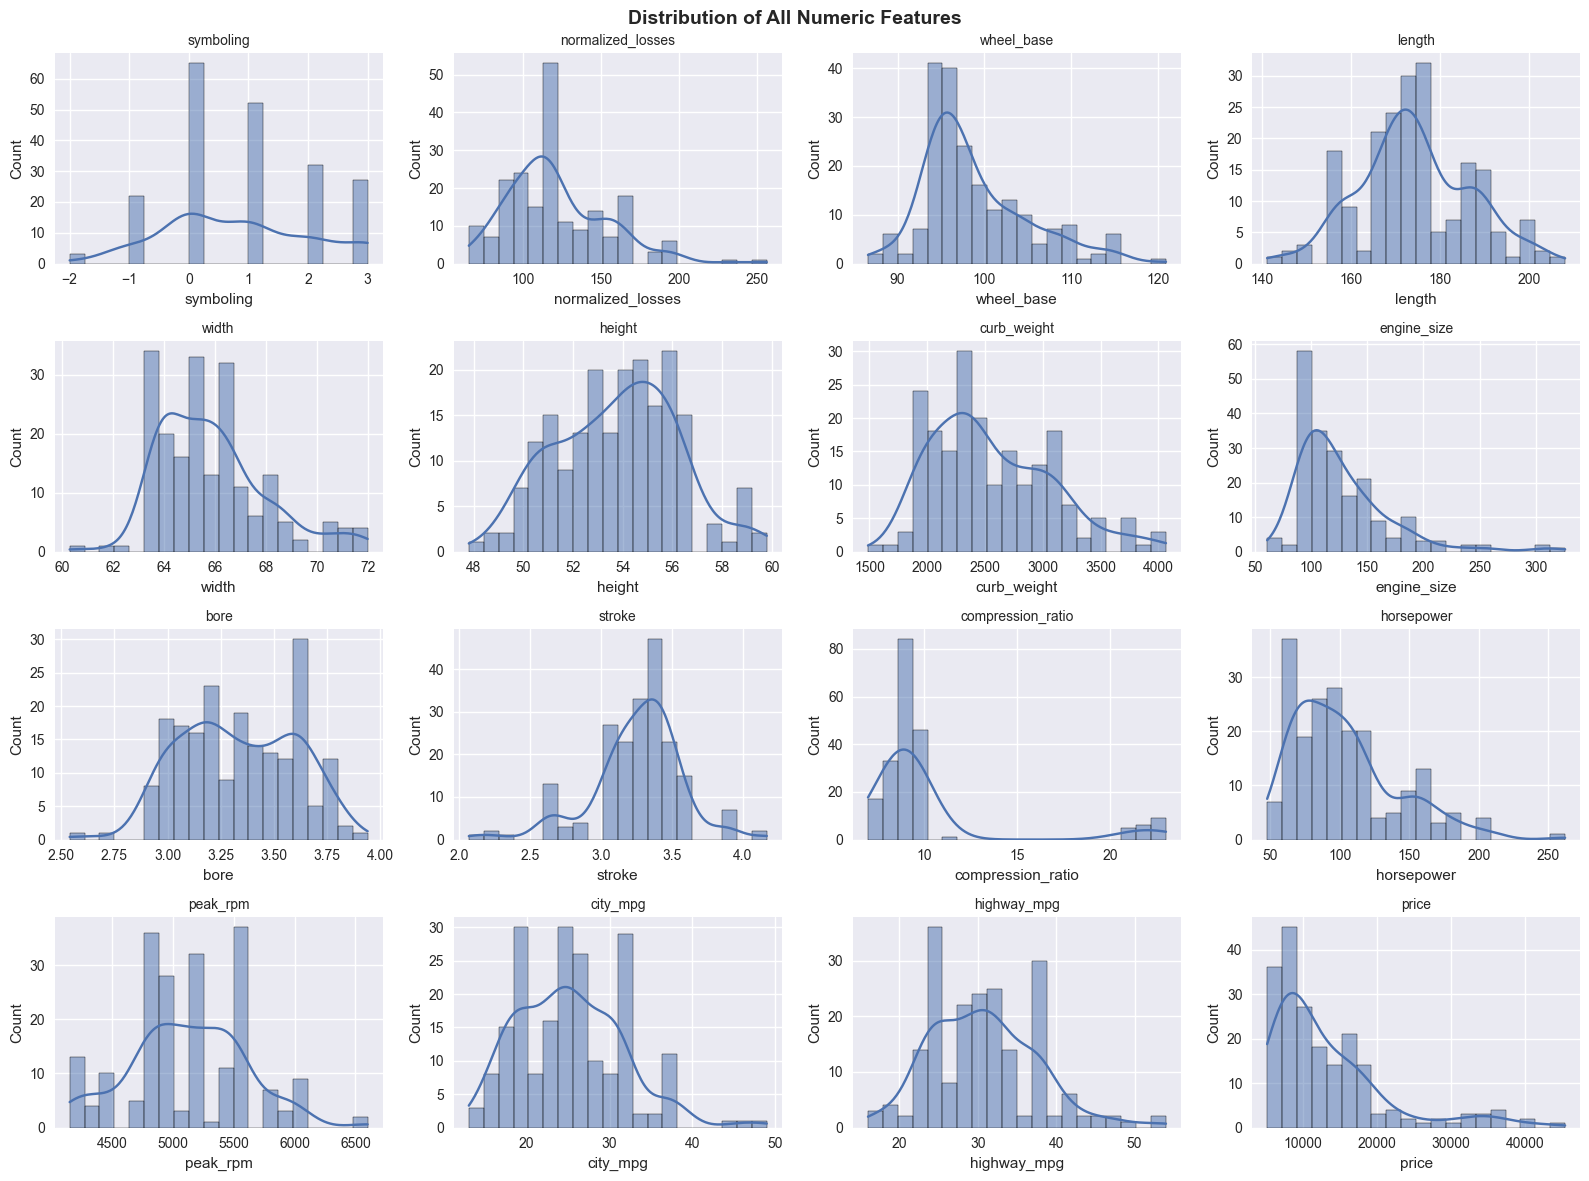

In [22]:
# ── STEP 4 — Distributions of All Numeric Features ──────────────────────────
# Loop through all numeric columns in df
# Plot a histplot (bins=20, kde=True) for each in a grid layout
# Hint: use axes.flatten() to convert the 2D grid to a 1D list
#       hide any unused panels with ax.set_visible(False)

num_cols = df.select_dtypes(include='number').columns.tolist()
n_cols_grid = 4
n_rows_grid = (len(num_cols) + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(16, n_rows_grid * 3))
axes_flat = axes.flatten()

# YOUR CODE HERE
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), bins = 20, kde = True, ax = axes_flat[i])
    axes_flat[i].set_title(col, fontsize = 10)

    
    

plt.suptitle('Distribution of All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 📝 Which columns look right-skewed? Which look roughly normal?
# ...

In [23]:
# ── STEP 5 — Top Correlations with Price ────────────────────────────────────
# Print top 5 features by |correlation| with price, with direction labels

# YOUR CODE HERE
corr = df.select_dtypes(include='number').corr()
top5 = corr['price'].drop('price').abs().sort_values(ascending=False).head(5)

print('Top 5 features by |correlation| with price:')
for rank, (feat, val) in enumerate(top5.items(), 1):
    direction = '↑ positive' if corr['price'][feat] > 0 else '↓ negative'
    print(f'  {rank}. {feat:25s}  r = {corr["price"][feat]:+.3f}  ({direction})')


Top 5 features by |correlation| with price:
  1. engine_size                r = +0.872  (↑ positive)
  2. curb_weight                r = +0.834  (↑ positive)
  3. horsepower                 r = +0.811  (↑ positive)
  4. width                      r = +0.751  (↑ positive)
  5. highway_mpg                r = -0.705  (↓ negative)


/var/folders/v_/r1j3wt6s44561bbtvn54rzph0000gn/T/ipykernel_1459/3635504361.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(make_counts.index, rotation=45, ha='right', fontsize=8)
/var/folders/v_/r1j3wt6s44561bbtvn54rzph0000gn/T/ipykernel_1459/3635504361.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(body_counts.index, rotation=30, ha='right')


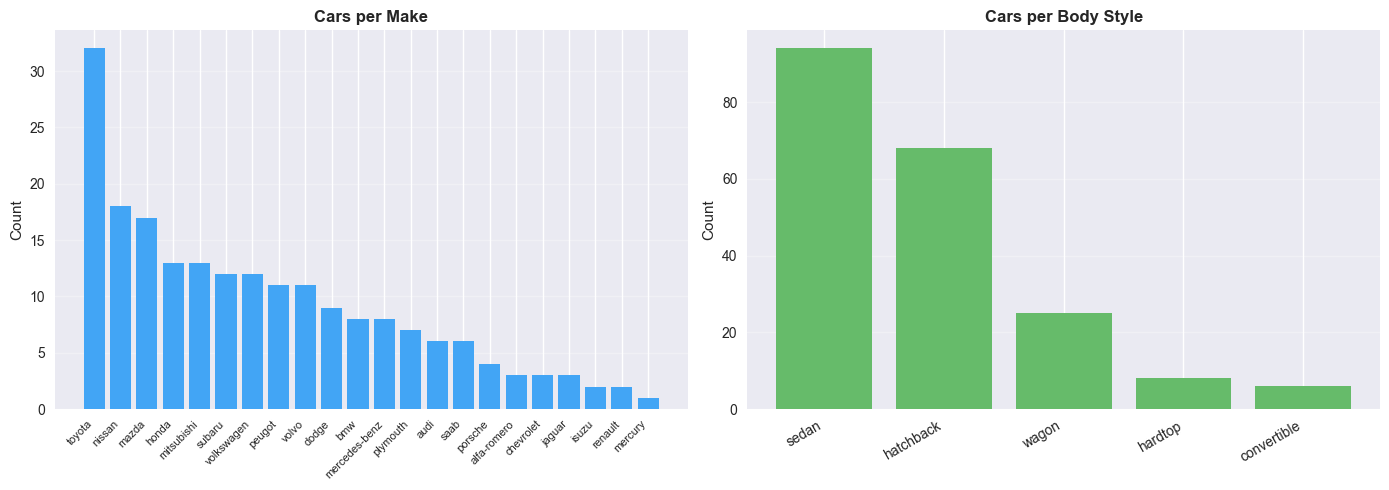

Makes with fewer than 5 cars:
make
porsche        4
alfa-romero    3
chevrolet      3
jaguar         3
isuzu          2
renault        2
mercury        1


<Figure size 800x550 with 0 Axes>

In [24]:
# ── STEP 6 — Class Balance ───────────────────────────────────────────────────
# Create 1×2 bar charts:
#   Left:  cars per make      (colour '#42A5F5')
#   Right: cars per body_style (colour '#66BB6A')
# Rotate x-labels for readability
# After the chart, print makes with fewer than 5 cars

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# YOUR CODE HERE

make_counts = df['make'].value_counts()
axes[0].bar(make_counts.index, make_counts.values, color='#42A5F5')
axes[0].set_xticklabels(make_counts.index, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Cars per Make', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

body_counts = df['body_style'].value_counts()
axes[1].bar(body_counts.index, body_counts.values, color='#66BB6A')
axes[1].set_xticklabels(body_counts.index, rotation=30, ha='right')
axes[1].set_title('Cars per Body Style', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Makes with fewer than 5 cars:')
print(make_counts[make_counts < 5].to_string())

plt.tight_layout()
plt.show()

# 📝 Why do makes with only 3–4 cars cause problems in groupby analysis and modelling?
# ...

---
# Part 4 — Correlation, Causation & Data Leakage

## ⚠️ The Most Important Lesson in EDA

> **High correlation does NOT mean one variable causes the other.**

`highway_mpg` has a strong negative correlation with `price` (r ≈ −0.70).  
Does better fuel economy make a car cheaper?

```
engine_size  ──→  price          (large engine → expensive)
     │
     └────────→  highway_mpg    (large engine → worse fuel economy)
```

`engine_size` is the **confounding variable**. Both `price` and `highway_mpg` are downstream of it.

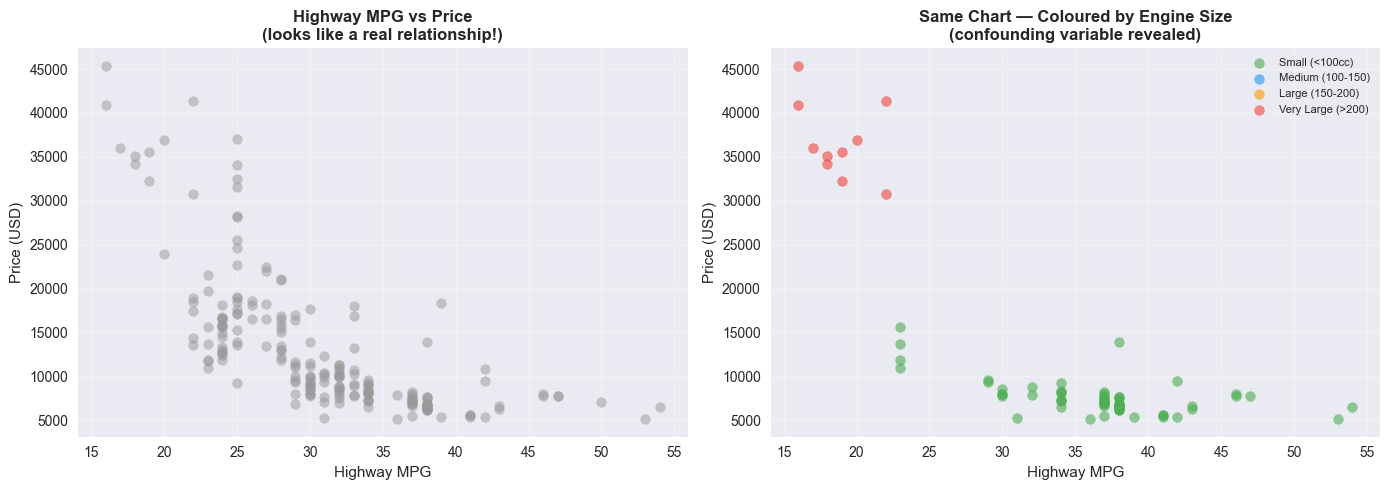

In [25]:
# ── TASK 10 — Confounding Variable Visualisation ────────────────────────────
# 1. Create an engine_size_bucket column using pd.cut:
#    bins=[0, 100, 150, 200, 400]
#    labels=['Small (<100cc)', 'Medium (100–150)', 'Large (150–200)', 'Very Large (>200)']
#
# 2. Create 1×2 subplots (figsize=(14,5)):
#    Left:  scatter highway_mpg vs price — all points grey (#999), title 'Looks like a real relationship!'
#    Right: same scatter but coloured by engine_size_bucket
#           palette = {'Small (<100cc)':'#4CAF50', 'Medium (100–150)':'#2196F3',
#                      'Large (150–200)':'#FF9800', 'Very Large (>200)':'#F44336'}
#           title 'Coloured by Engine Size — Confound Revealed'
# ─────────────────────────────────────────────────────────────────────────────

# YOUR CODE HERE
df['engine_size_bucket'] = pd.cut(
    df['engine_size'],
    bins=[0, 100, 150, 200, 400],
    labels=['Small (<100cc)', 'Medium (100–150)', 'Large (150–200)', 'Very Large (>200)']
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['highway_mpg'], df['price'], alpha=0.5, color='#999')
axes[0].set_title('Highway MPG vs Price\n(looks like a real relationship!)', fontweight='bold')
axes[0].set_xlabel('Highway MPG')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(alpha=0.3)

palette = {
    'Small (<100cc)':    '#4CAF50',
    'Medium (100-150)':  '#2196F3',
    'Large (150-200)':   '#FF9800',
    'Very Large (>200)': '#F44336'
}
for bucket, colour in palette.items():
    subset = df[df['engine_size_bucket'] == bucket]
    axes[1].scatter(subset['highway_mpg'], subset['price'],
                    label=bucket, color=colour, alpha=0.6, s=50)

axes[1].set_title('Same Chart — Coloured by Engine Size\n(confounding variable revealed)', fontweight='bold')
axes[1].set_xlabel('Highway MPG')
axes[1].set_ylabel('Price (USD)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 📝 After seeing the right chart: does highway_mpg look like a useful
# independent predictor of price? Why or why not?
# ...

## Data Leakage

**Data leakage** = information that wouldn't be available at prediction time leaking into training data.  
Result: the model looks great in training → **fails completely in production**.

**Example — `normalized_losses`:** An insurance risk score partly calculated from claim costs, which correlate with repair costs, which correlate with car price. You would not have this score for a car whose price you are trying to predict.

| Leakage Type | Description |
|---|---|
| **Target proxy** | Feature derived from or correlated with target |
| **Future data** | Feature uses information from after the predicted event |
| **Label-derived** | Feature computed directly from the label |

In [26]:
# ── TASK 11 — Flag Potential Leakage ────────────────────────────────────────
# Review the columns below. Flag any that might cause leakage when predicting 'price'.
# For each, explain WHY in a comment.

print('All columns:')
for col in df.columns:
    print(f'  {col}')

# YOUR FLAGS:
# Column: ...  Reason: ...
# Column: ...  Reason: ...

All columns:
  symboling
  normalized_losses
  make
  fuel_type
  aspiration
  num_of_doors
  body_style
  drive_wheels
  engine_location
  wheel_base
  length
  width
  height
  curb_weight
  engine_type
  num_of_cylinders
  engine_size
  fuel_system
  bore
  stroke
  compression_ratio
  horsepower
  peak_rpm
  city_mpg
  highway_mpg
  price
  engine_size_bucket


In [ ]:
df_raw['price'].max()

np.float64(45400.0)

---
# Part 5 — Outlier Detection & Final Report

## Why Outliers Matter
- **EDA:** A mean inflated by 3 Ferrari-level outliers doesn't represent the typical car
- **Modelling:** Outliers pull regression lines off course

## Method 1 — IQR
```
IQR = Q3 − Q1
Lower fence = Q1 − 1.5 × IQR
Upper fence = Q3 + 1.5 × IQR
```
Robust to skewed distributions — doesn't assume normality.

## Method 2 — Z-Score
```
z = (value − mean) / std    →    flag |z| > 3
```
Assumes approximate normality. Less robust on skewed data like `price`.

In [37]:
# ── TASK 12 — Write the IQR outlier detection function ──────────────────────
# Complete the function below.
# It should return: (outlier_df, lower_fence, upper_fence)

def detect_outliers_iqr(df: pd.DataFrame, col: str):
    """Return (outlier_rows_df, lower_fence, upper_fence) using IQR method."""
    q3 = df[col].quantile(0.75)
    q1  = df[col].quantile(0.25)
    iqr = q3 - q1
    
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr

    mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    return df[mask], lower_bound, upper_bound

for col in ['price', 'horsepower', 'engine_size']:
    outliers, low, high = detect_outliers_iqr(df, col)
    print(f'{col}: fences=[{low:.1f}, {high:.1f}]  outliers={len(outliers)}')
# # Test it on price, horsepower, engine_size
# for col in ['price', 'horsepower', 'engine_size']:
#     outliers, low, high = detect_outliers_iqr(df, col)
#     print(f'{col}: fences=[{low:.1f}, {high:.1f}]  outliers={len(outliers)}')

price: fences=[-5312.5, 29587.5]  outliers=14
horsepower: fences=[1.0, 185.0]  outliers=5
engine_size: fences=[33.5, 205.5]  outliers=10


In [38]:
# ── TASK 13 — Write the Z-Score outlier detection function ──────────────────
# Complete the function. Flag rows where |z| > threshold (default 3.0)
from scipy import  stats

def detect_outliers_zscore(df: pd.DataFrame, col: str, threshold: float = 3.0) -> pd.DataFrame:
    """Return outlier rows using Z-score method."""
    col_clean = df[col].dropna()
    z_scores = np.abs(stats.zscore(col_clean))
    outlier_idx = col_clean.index[z_scores > threshold]
    return df.loc[outlier_idx]

# print(f"{'Column':<15} {'IQR':>6} {'Z-Score':>9}")
# print('-' * 32)
# for col in ['price', 'horsepower', 'engine_size']:
#     n_iqr = len(detect_outliers_iqr(df, col)[0])
#     n_z   = len(detect_outliers_zscore(df, col))
#     print(f'{col:<15} {n_iqr:>6} {n_z:>9}')


# Compare counts: IQR vs Z-score
print(f"{'Column':<15} {'IQR':>6} {'Z-Score':>9}")
print('-' * 32)
for col in ['price', 'horsepower', 'engine_size']:
    n_iqr = len(detect_outliers_iqr(df, col)[0])
    n_z   = len(detect_outliers_zscore(df, col))
    print(f'{col:<15} {n_iqr:>6} {n_z:>9}')

# 📝 Which method flags more outliers? Why might they disagree on skewed data?
# ...

Column             IQR   Z-Score
--------------------------------
price               14         4
horsepower           5         1
engine_size         10         5


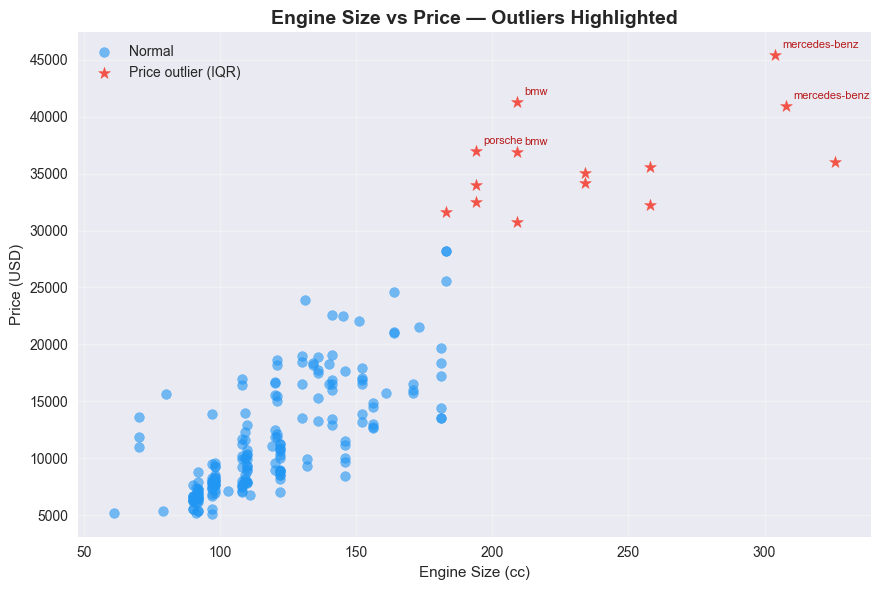


Makes in outlier group:
              make   body_style  engine_size    price
74   mercedes-benz      hardtop          304  45400.0
16             bmw        sedan          209  41315.0
73   mercedes-benz        sedan          308  40960.0
128        porsche  convertible          194  37028.0
17             bmw        sedan          209  36880.0
49          jaguar        sedan          326  36000.0
48          jaguar        sedan          258  35550.0
72   mercedes-benz  convertible          234  35056.0
71   mercedes-benz        sedan          234  34184.0
127        porsche      hardtop          194  34028.0
126        porsche      hardtop          194  32528.0
47          jaguar        sedan          258  32250.0
70   mercedes-benz        sedan          183  31600.0
15             bmw        sedan          209  30760.0


In [30]:
# ── TASK 14 — Visualise Outliers ─────────────────────────────────────────────
# Scatter plot: engine_size (x) vs price (y)
# Normal points: blue (#2196F3), s=50
# Outlier points (IQR on price): red (#F44336), s=80, marker='*'
# Annotate the top 5 highest-price outliers with their 'make'
#   Use ax.annotate(make, (engine_size, price), textcoords='offset points', xytext=(5,5))

outlier_df, _, _ = detect_outliers_iqr(df, 'price')
normal_df = df[~df.index.isin(outlier_df.index)]

fig, ax = plt.subplots(figsize=(9, 6))

# YOUR CODE HERE
ax.scatter(normal_df['engine_size'], normal_df['price'],
           color='#2196F3', alpha=0.6, s=50, label='Normal')
ax.scatter(outlier_df['engine_size'], outlier_df['price'],
           color='#F44336', alpha=0.9, s=80, marker='*',
           label=f'Price outlier (IQR)')

top_outliers = outlier_df.nlargest(5, 'price')
for _, row in top_outliers.iterrows():
    ax.annotate(row['make'],
                (row['engine_size'], row['price']),
                textcoords='offset points', xytext=(5, 5),
                fontsize=8, color='#B71C1C')


ax.set_title('Engine Size vs Price — Outliers Highlighted', fontsize=14, fontweight='bold')
ax.set_xlabel('Engine Size (cc)')
ax.set_ylabel('Price (USD)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print('\nMakes in outlier group:')
print(outlier_df[['make', 'body_style', 'engine_size', 'price']].sort_values('price', ascending=False))

In [31]:
# ── TASK 15 — Complete the Outlier Report ────────────────────────────────────
# Fill in the 'Error or Genuine' and 'Recommended Action' columns
# based on the scatter plot and the makes you saw above

report = pd.DataFrame({
    'Column':               ['price', 'horsepower', 'engine_size'],
    'N Outliers (IQR)':     [None, None, None],   # fill programmatically
    'N Outliers (Z)':       [None, None, None],   # fill programmatically
    'Error or Genuine':     ['???', '???', '???'], # YOUR ASSESSMENT
    'Recommended Action':   ['???', '???', '???']  # YOUR RECOMMENDATION
})

for i, col in enumerate(['price', 'horsepower', 'engine_size']):
    report.at[i, 'N Outliers (IQR)'] = len(detect_outliers_iqr(df, col)[0])
    report.at[i, 'N Outliers (Z)']   = len(detect_outliers_zscore(df, col))

print('=== OUTLIER REPORT ===')
print(report.to_string(index=False))

=== OUTLIER REPORT ===
     Column N Outliers (IQR) N Outliers (Z) Error or Genuine Recommended Action
      price               14              4              ???                ???
 horsepower                5              1              ???                ???
engine_size               10              5              ???                ???


---
# 📝 Day 4 Summary

| Concept | Key Takeaway |
|---------|-------------|
| **Figure vs Axes** | Figure = canvas. Axes = plot area. All real work on the Axes. |
| **Seaborn** | Built on Matplotlib. Handles statistics and grouping automatically. |
| **Feature types** | Continuous / Discrete / Nominal / Ordinal / Boolean — affects every decision. |
| **EDA workflow** | Shape → dtypes → nulls → distributions → correlations → class balance. |
| **Correlation ≠ Causation** | Look for confounding variables before drawing conclusions. |
| **Data leakage** | If a feature uses info unavailable at prediction time — drop it. |
| **Outlier removal** | Only drop data errors. Legitimate rare values carry real information. |

---
# 🏠 Assignment

1. **Confounding hunt:** Pick any two features with |r| > 0.6 (excluding price). Argue whether their correlation is causal or confounded by a third variable.

2. **Leakage flag:** Is `symboling` safe to use as a feature when predicting price? Write 3–5 sentences justifying your answer.

3. **Ordinal mapping:** `num_of_cylinders` stores numbers as words. Write code to map it to integers (`'two'→2`, `'three'→3`, ..., `'twelve'→12`). Then plot average price by cylinder count.

4. **Bonus:** Add `compression_ratio` vs `price` as a 5th panel to your Task 2 grid. Does it show a strong relationship?